In [1]:
import neural_additive_models.data_utils as data_utils
import neural_additive_models.graph_builder as graph_builder

import os.path as osp

In [2]:
from utils import load_col_min_max, inverse_min_max_scaler

Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
dataset_name = 'Recidivism'
is_regression = dataset_name in ['Housing', 'Fico']
data =  data_utils.load_dataset(dataset_name)
data_x, data_y, column_names = data
col_min_max = load_col_min_max(dataset_name)

In [4]:
from utils import load_nam_checkpoint
import numpy as np

ckpt_dir = r"./compas/fold_5/split_1/model_0/best_checkpoint"
nam, sess = load_nam_checkpoint(ckpt_dir)

Using checkpoint: ./compas/fold_5/split_1/model_0/best_checkpoint\model.ckpt-320
Feature widths: [64, 4, 12, 4, 64, 64]
Num input features: 6
INFO:tensorflow:Restoring parameters from ./compas/fold_5/split_1/model_0/best_checkpoint\model.ckpt-320
✅ Restored NAM from checkpoint.


In [5]:
from utils import get_test_predictions, compute_features, get_feature_predictions

# --- Test set predictions ---
test_predictions = get_test_predictions(nam, data_x.astype(np.float32), sess, batch_size=50000)
print("Predictions length:", len(test_predictions))

# --- Feature-wise predictions (shape functions) ---
unique_features = compute_features(dataset_name)

feature_predictions = get_feature_predictions(nam, dataset_name, sess)

# --- Evaluate RMSE or AUROC ---

test_metric = graph_builder.calculate_metric(
    data_y, test_predictions, regression=is_regression)
metric_str = 'RMSE' if is_regression else 'AUROC'
print(f'{metric_str}: {test_metric:.4f}')

Predictions length: 6172
AUROC: 0.7463


In [6]:
from utils import prepare_feature_arrays, get_dataset_config, compute_mean_predictions

# Step 1: Prepare data
SINGLE_FEATURES_ORIGINAL, UNIQUE_FEATURES_ORIGINAL, UNIQUE_FEATURES = prepare_feature_arrays(
    data_x, column_names, col_min_max, inverse_min_max_scaler
)

# Step 2: Load dataset-specific config
COL_NAMES, FEATURE_LABEL_MAPPING, CATEGORICAL_NAMES = get_dataset_config(dataset_name, column_names)

# Step 3: Align predictions
avg_hist_data, MEAN_PRED, ALL_INDICES = compute_mean_predictions(
    data_x, column_names, UNIQUE_FEATURES, feature_predictions
)


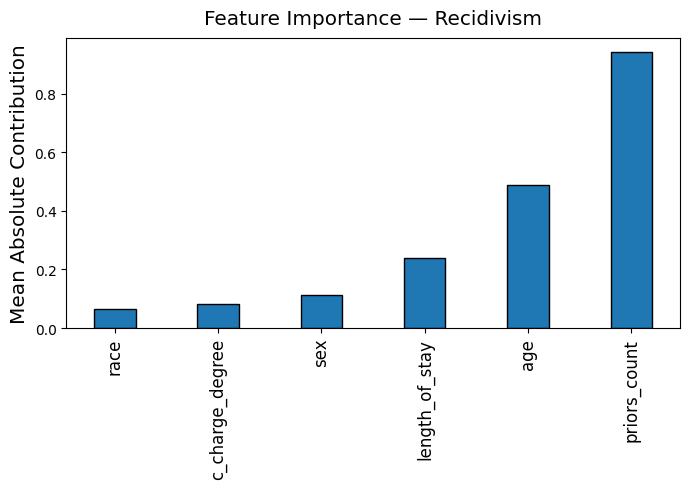

In [7]:
from utils import compute_mean_feature_importance, plot_mean_feature_importance

feature_names, importances = compute_mean_feature_importance(avg_hist_data, MEAN_PRED)
fig = plot_mean_feature_importance(feature_names, importances, dataset_name)

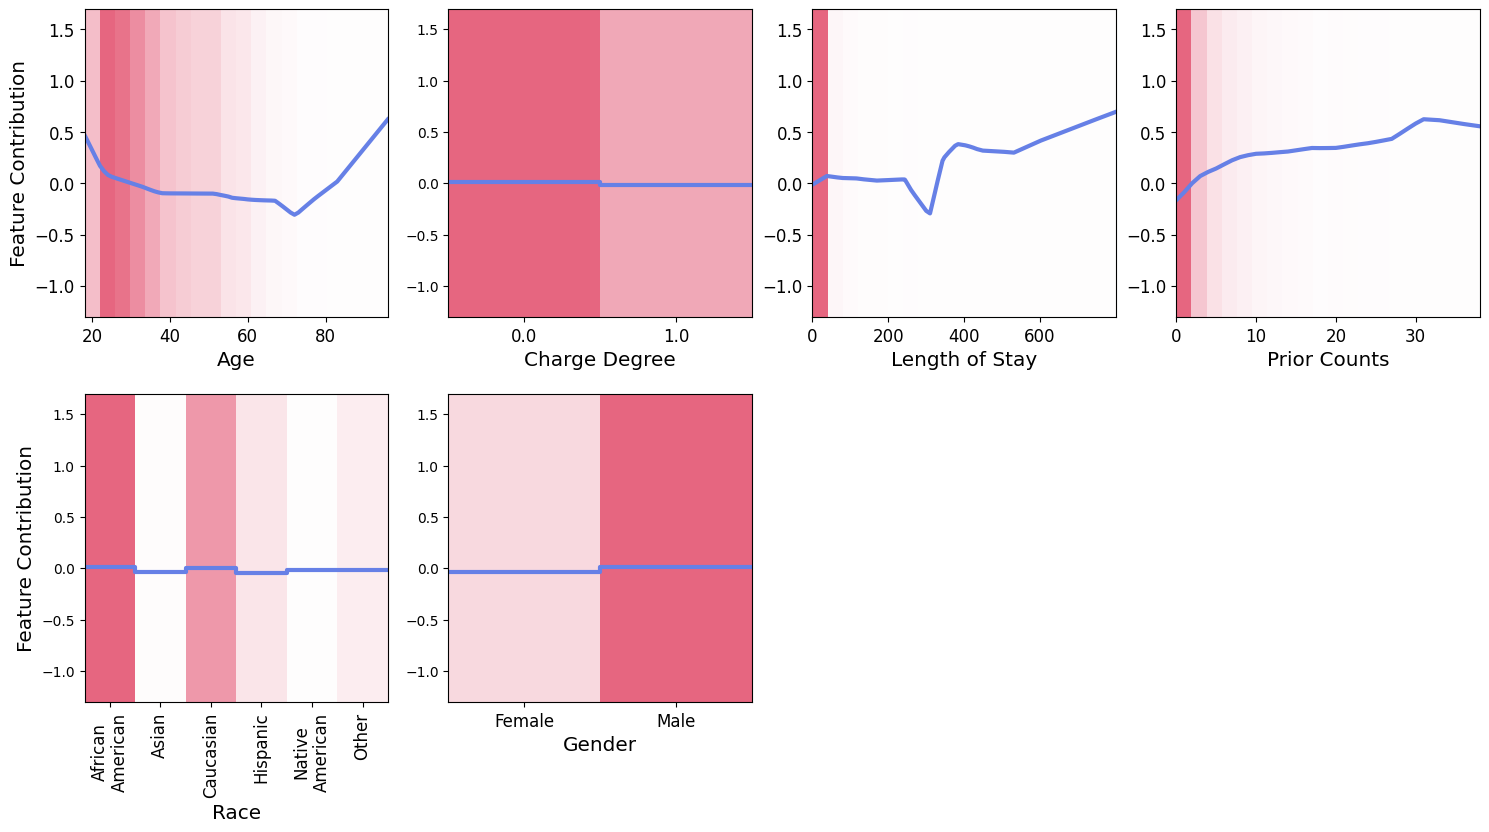

In [11]:
from utils import plot_nam_contributions_with_density
plt = plot_nam_contributions_with_density(
    hist_data=avg_hist_data,
    unique_features=UNIQUE_FEATURES_ORIGINAL,
    single_features=SINGLE_FEATURES_ORIGINAL,
    categorical_names=CATEGORICAL_NAMES,
    col_mapping=COL_NAMES[dataset_name],
    feature_mapping=FEATURE_LABEL_MAPPING[dataset_name],
    mean_pred=MEAN_PRED,
    feature_to_use=column_names
)


In [8]:
all_preds_per_fold = [[] for _ in range(5)]
all_hist_data = []
all_mean_pred = []

for fold in range(5, 6):             # 5 folds
    fold_idx = fold - 1
    print(f"Processing fold {fold}...")
    for split in range(1, 21):       # 20 splits per fold
        if split % 5 == 0:
            print(f"  Processing split {split}...")
        ckpt_dir = f"./compas/fold_{fold}/split_{split}/model_0/best_checkpoint"

        nam, sess = load_nam_checkpoint(ckpt_dir)
        preds = get_test_predictions(nam, data_x.astype(np.float32), sess)

        all_preds_per_fold[fold_idx].append(preds)

        feature_predictions = get_feature_predictions(nam, dataset_name, sess)
        avg_hist_data, mean_pred, _ = compute_mean_predictions(
            data_x, column_names, UNIQUE_FEATURES, feature_predictions
        )

        all_hist_data.append(avg_hist_data)
        all_mean_pred.append(mean_pred)


Processing fold 5...
Using checkpoint: ./compas/fold_5/split_1/model_0/best_checkpoint\model.ckpt-320
Feature widths: [64, 4, 12, 4, 64, 64]
Num input features: 6
INFO:tensorflow:Restoring parameters from ./compas/fold_5/split_1/model_0/best_checkpoint\model.ckpt-320
✅ Restored NAM from checkpoint.
Using checkpoint: ./compas/fold_5/split_2/model_0/best_checkpoint\model.ckpt-320
Feature widths: [64, 4, 12, 4, 64, 64]
Num input features: 6
INFO:tensorflow:Restoring parameters from ./compas/fold_5/split_2/model_0/best_checkpoint\model.ckpt-320
✅ Restored NAM from checkpoint.
Using checkpoint: ./compas/fold_5/split_3/model_0/best_checkpoint\model.ckpt-280
Feature widths: [64, 4, 12, 4, 64, 64]
Num input features: 6
INFO:tensorflow:Restoring parameters from ./compas/fold_5/split_3/model_0/best_checkpoint\model.ckpt-280
✅ Restored NAM from checkpoint.
Using checkpoint: ./compas/fold_5/split_4/model_0/best_checkpoint\model.ckpt-160
Feature widths: [64, 4, 12, 4, 64, 64]
Num input features: 6


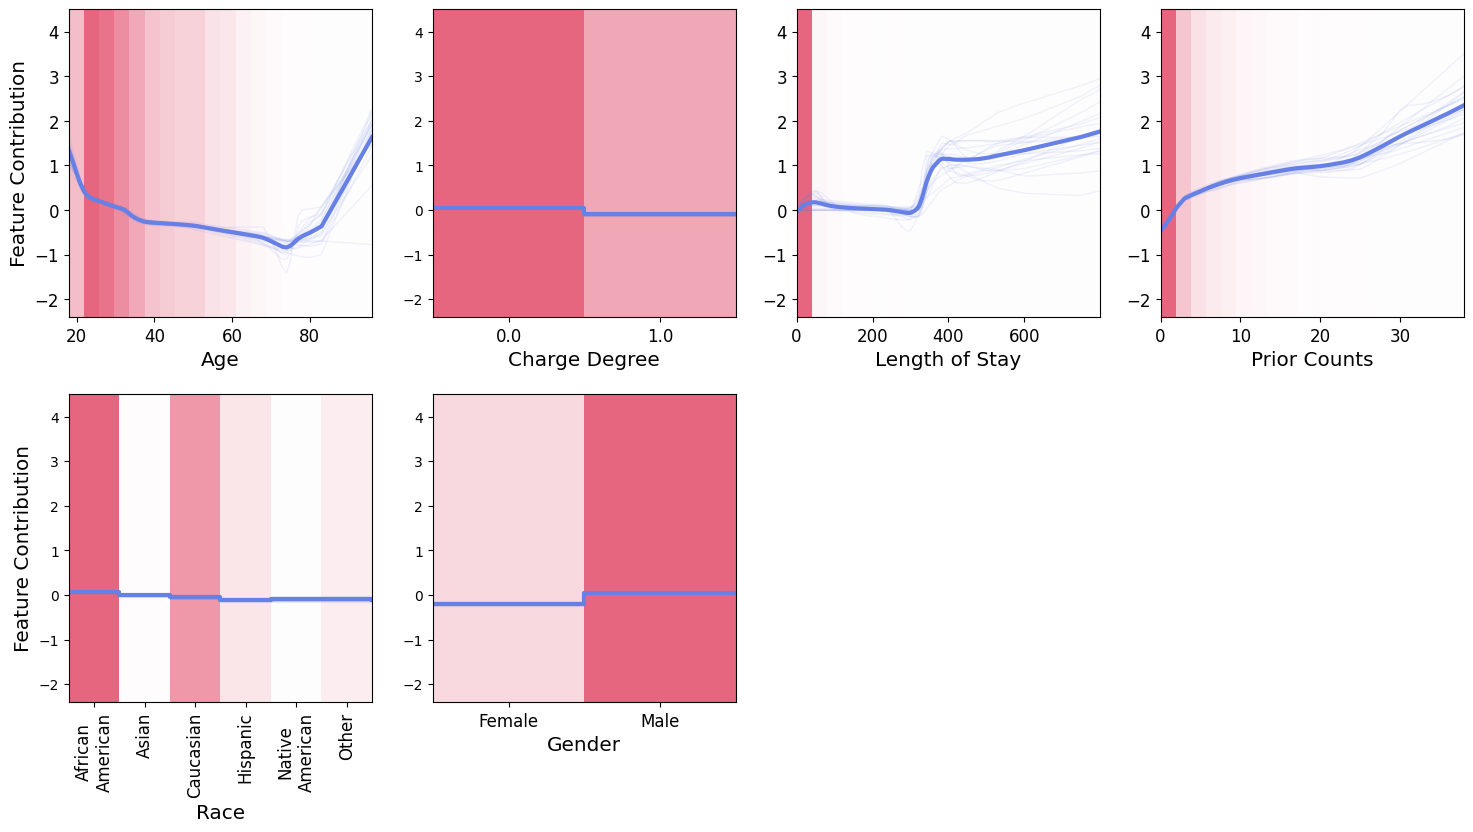

In [20]:
from utils import plot_nam_contributions_with_density

fig = plot_nam_contributions_with_density(
    hist_data=all_hist_data,                 # LIST of dicts (one per model)
    unique_features=UNIQUE_FEATURES_ORIGINAL,
    single_features=SINGLE_FEATURES_ORIGINAL,
    categorical_names=CATEGORICAL_NAMES,
    col_mapping=COL_NAMES[dataset_name],
    feature_mapping=FEATURE_LABEL_MAPPING[dataset_name],
    mean_pred=all_mean_pred,                 # LIST of dicts (same length as hist_data)
    feature_to_use=column_names
)


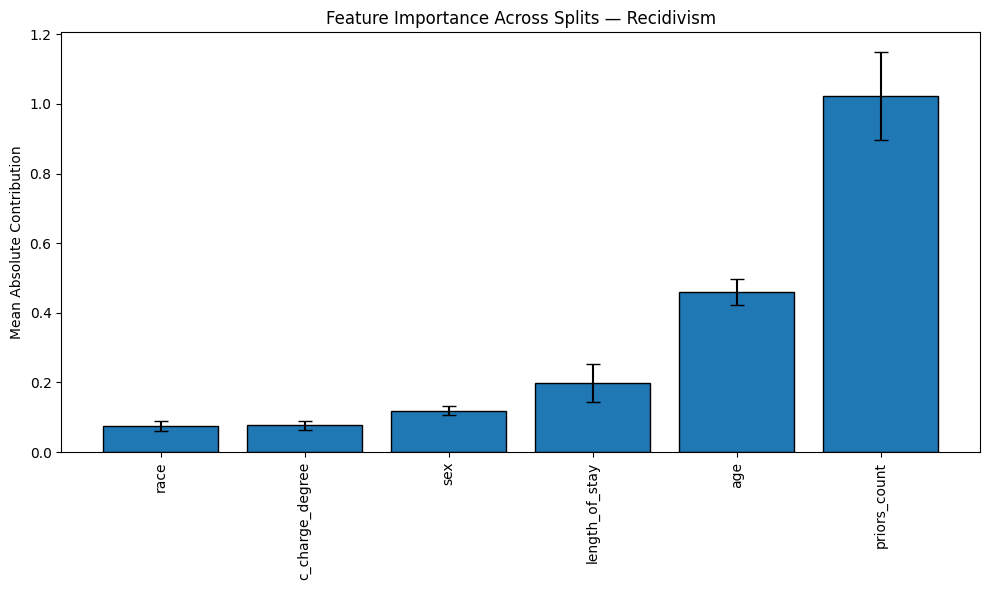

In [10]:
from utils import compute_mean_feature_importance
import numpy as np
import matplotlib.pyplot as plt

# Compute per-split importances
all_feature_importances = []

for avg_hist_data, mean_pred in zip(all_hist_data, all_mean_pred):
    feature_names, importances = compute_mean_feature_importance(avg_hist_data, mean_pred)
    all_feature_importances.append(importances)

# Combine into matrix (splits x features)
all_feature_importances = np.vstack(all_feature_importances)

# Average and std across splits
importance_mean = all_feature_importances.mean(axis=0)
importance_std  = all_feature_importances.std(axis=0)

# Sort features by mean importance
sorted_idx = np.argsort(importance_mean)
sorted_features = np.array(feature_names)[sorted_idx]
sorted_mean = importance_mean[sorted_idx]
sorted_std  = importance_std[sorted_idx]

# Plot averaged feature importance with error bars
plt.figure(figsize=(10, 6))
plt.bar(sorted_features, sorted_mean, yerr=sorted_std, capsize=5, edgecolor="k")
plt.xticks(rotation=90)
plt.ylabel("Mean Absolute Contribution")
plt.title(f"Feature Importance Across Splits — {dataset_name}")
plt.tight_layout()
plt.show()


In [ ]:
fold_rmses = []

for fold_idx in range(5):
    preds = np.vstack(all_preds_per_fold[fold_idx])   # (20, n_samples)
    ensemble_pred = preds.mean(axis=0)
    
    rmse = graph_builder.calculate_metric(
        data_y,
        ensemble_pred,
        regression=True
    )
    fold_rmses.append(rmse)
    print(f"Fold {fold_idx+1} RMSE: {rmse:.4f}")

fold_rmses = np.array(fold_rmses)
avg_rmse = fold_rmses.mean()
std_rmse = fold_rmses.std()

print(f"\nAverage Ensemble RMSE across folds: {avg_rmse:.4f}")
print(f"Std of Ensemble RMSE across folds: {std_rmse:.4f}")
